## Experiment 2

We now reproduce the second experiment in §5.1, showing that classification of datasets is easy. We will use a SVM model as suggested by the authors.

In [1]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

# names of datasets used
ds_names = ['qqp', 'qnli', 'wiki', 'books']
# sample only 40000 from each dataset due to memory concerns
n = 40000
# seeded rng
rng = np.random.default_rng(1)

We collect the sample.

In [2]:
# examples and example labels
# will collect here, across datasets
X, Y = [], []

for idx, ds in enumerate(ds_names):
    # mmap for speed, remove this parameter if not enough space in memory
    embed = np.load(f'../../../embeds/full/{ds}_embed.npy', mmap_mode='r')
    # get a sample of n dataset items (as indices)
    sample = rng.choice(embed.shape[0], n, replace=False)
    # append embeds for the indices in sample to X
    X.append(np.array(embed[sample]))
    # append 0/1/2/3 repeated enough times to Y
    Y.append(np.full(n, idx))

# shapes (4, 40000, 768) to (160000, 768)
X = np.concat(X)
Y = np.concat(Y)

We prepare a train-test split and train the SVM classifier.

In [3]:
# train-test split at 20% testing data
# stratify=Y makes no class (even slightly) over-represented by the random draw
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1)

# for memory
del X, Y 

scaler = StandardScaler().fit(X_train)
# normalize data
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

# linear SVM model
svm = LinearSVC(dual=False, C=1.0, random_state=1).fit(X_train, Y_train)
# predict on test data
Y_pred = svm.predict(X_test)

In [9]:
# get stats for display
acc    = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred, target_names=ds_names, digits=2)
cmat   = confusion_matrix(Y_test, Y_pred, normalize='true')

# show accuracy and classification report
print(f'Accuracy = {(100 * acc):.2f}%\n{report}')

Accuracy = 88.41%
              precision    recall  f1-score   support

         qqp       0.99      1.00      0.99      8000
        qnli       0.78      0.81      0.80      8000
        wiki       0.79      0.75      0.77      8000
       books       0.96      0.98      0.97      8000

    accuracy                           0.88     32000
   macro avg       0.88      0.88      0.88     32000
weighted avg       0.88      0.88      0.88     32000



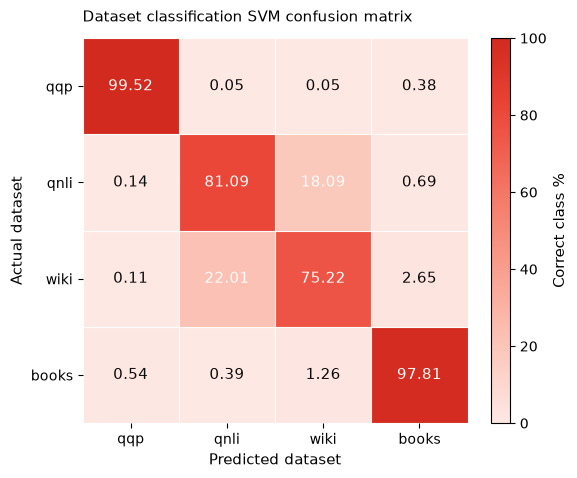

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# gradient, light = low (0), dark = high (100) values
cmap = LinearSegmentedColormap.from_list('seq_salmon', 
        ['#fee8e4', '#fddad3', '#fccbbf', '#fbbcae', 
         '#faac9c', '#f89b8b', '#f78b7a', '#f57a69', 
         '#f26858', '#ef5546', '#e94335', '#de3529',
         '#d22a1e'])

# background color
bg = '#fcfcfb'

# scale confusion matrix values into percentages
cmat = cmat * 100

# create plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cmat, cmap=cmap, vmin=0, vmax=100)

# make gap between cells using gaps between tick marks
ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
# make the grid color same as the background
ax.grid(which='minor', color=bg)
# disable the ticks
ax.tick_params(which='minor', length=0)

# label each cell
for i in range(4):
    for j in range(4):
        val = cmat[i, j]

        # determine the color for contrast
        val_color = None
        # high values = dark background, so use bg white
        # anything above 5.0% will be using this color
        if val >= 5.0:
            val_color = bg
        # low values = light background, so use a black
        else:
            val_color = '#0b0b0b'

        # finally add text to cell
        ax.text(j, i, f'{val:.2f}', 
                ha='center',
                va='center',
                fontsize=11,
                color=val_color)

# tick labels correspond to the datasets
tick_labels = ['qqp', 'qnli', 'wiki', 'books']

# set them on the x-axis and y-axis
ax.set_xticks(range(4), tick_labels)
ax.set_yticks(range(4), tick_labels)

# x-axis is for model output
ax.set_xlabel('Predicted dataset', fontsize=11)
# y-axis is for expected output
ax.set_ylabel('Actual dataset', fontsize=11)

# remove the "box" around the graph
for spine in ax.spines.values(): 
    spine.set_visible(False)

ax.set_title(f'Dataset classification SVM confusion matrix',
             fontsize=11, 
             pad=12, 
             loc='left')

# add a color bar gradient to the right
cbar = fig.colorbar(im, 
                    ax=ax, 
                    fraction=0.05, 
                    pad=0.05)
# label it
cbar.set_label('Correct class %', fontsize=11)

# show the plot
plt.show()
